# Cause of Unfairness - Dataset Bias Analysis
## CSC4009 Assignment 1

This notebook generates visualizations and statistics for the Cause of Unfairness analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the dataset
data = pd.read_csv('CSC4009-AI-Fairness-datasets/adult.data.csv', na_values='?').dropna()
print(f"Dataset loaded: {len(data):,} samples")

Dataset loaded: 30,162 samples


## 1. Contingency Tables

In [4]:
# Contingency Table: Sex × Income
sex_income_ct = pd.crosstab(data['sex'], data['income-class'], margins=True)
sex_income_pct = pd.crosstab(data['sex'], data['income-class'], normalize='index') * 100

print("=" * 60)
print("CONTINGENCY TABLE: SEX × INCOME")
print("=" * 60)
print("\nCounts:")
print(sex_income_ct)
print("\nPercentages (row-wise):")
print(sex_income_pct.round(2))

CONTINGENCY TABLE: SEX × INCOME

Counts:
income-class  <=50K  >50K    All
sex                             
Female         8670  1112   9782
Male          13984  6396  20380
All           22654  7508  30162

Percentages (row-wise):
income-class  <=50K   >50K
sex                       
Female        88.63  11.37
Male          68.62  31.38


In [5]:
# Contingency Table: Race × Income
race_income_ct = pd.crosstab(data['race'], data['income-class'], margins=True)
race_income_pct = pd.crosstab(data['race'], data['income-class'], normalize='index') * 100

print("=" * 60)
print("CONTINGENCY TABLE: RACE × INCOME")
print("=" * 60)
print("\nCounts:")
print(race_income_ct)
print("\nPercentages (row-wise):")
print(race_income_pct.round(2))

CONTINGENCY TABLE: RACE × INCOME

Counts:
income-class        <=50K  >50K    All
race                                  
Amer-Indian-Eskimo    252    34    286
Asian-Pac-Islander    647   248    895
Black                2451   366   2817
Other                 210    21    231
White               19094  6839  25933
All                 22654  7508  30162

Percentages (row-wise):
income-class        <=50K   >50K
race                            
Amer-Indian-Eskimo  88.11  11.89
Asian-Pac-Islander  72.29  27.71
Black               87.01  12.99
Other               90.91   9.09
White               73.63  26.37


## 2. Stacked Bar Charts

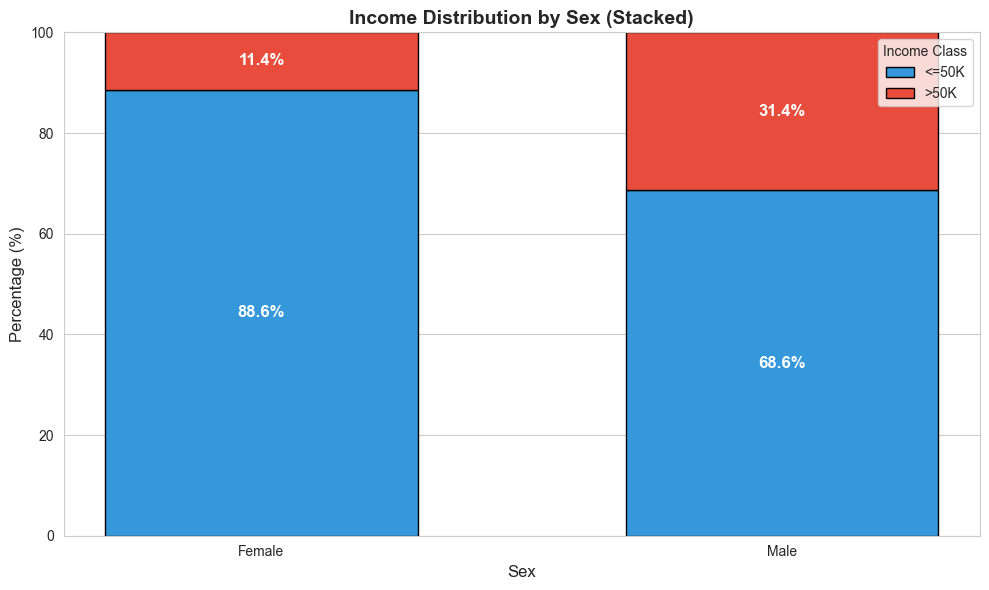

Chart saved as 'charts/dataset_bias_sex_stacked.png'


In [6]:
# Stacked Bar Chart: Income by Sex
fig, ax = plt.subplots(figsize=(10, 6))

sex_pct = sex_income_pct.copy()
x = np.arange(len(sex_pct))
width = 0.6

bars1 = ax.bar(sex_pct.index, sex_pct['<=50K'], width, label='<=50K', color='#3498db', edgecolor='black')
bars2 = ax.bar(sex_pct.index, sex_pct['>50K'], width, bottom=sex_pct['<=50K'], label='>50K', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Sex', fontsize=12)
ax.set_title('Income Distribution by Sex (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Income Class', loc='upper right')
ax.set_ylim(0, 100)

# Add percentage labels
for i, (idx, row) in enumerate(sex_pct.iterrows()):
    ax.text(i, row['<=50K']/2, f"{row['<=50K']:.1f}%", ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(i, row['<=50K'] + row['>50K']/2, f"{row['>50K']:.1f}%", ha='center', va='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('charts/dataset_bias_sex_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/dataset_bias_sex_stacked.png'")

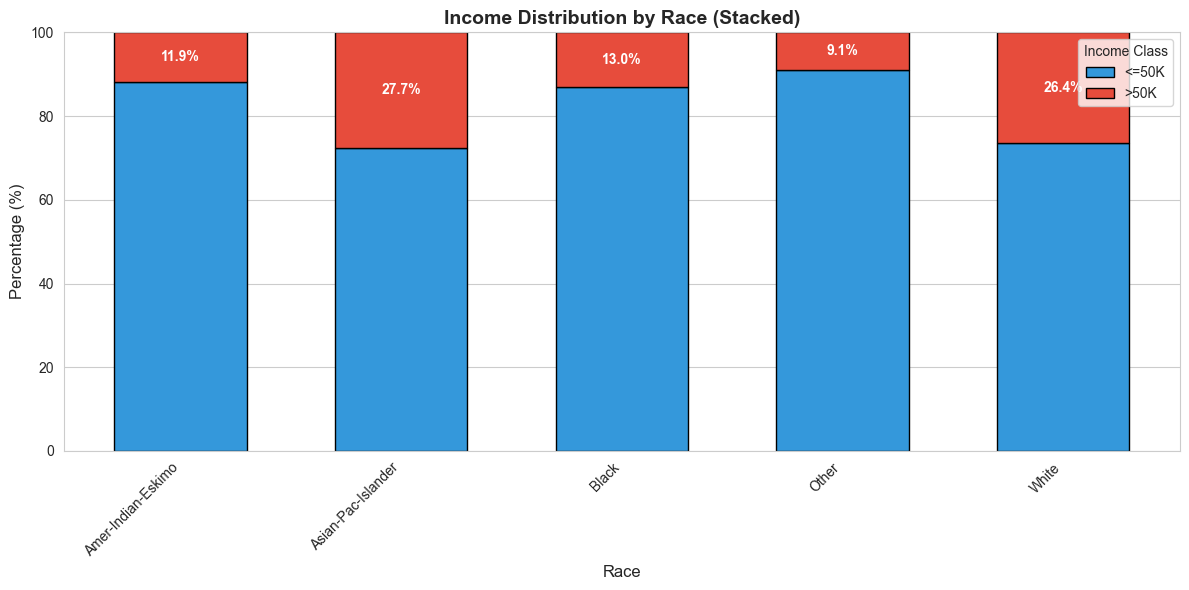

Chart saved as 'charts/dataset_bias_race_stacked.png'


In [7]:
# Stacked Bar Chart: Income by Race
fig, ax = plt.subplots(figsize=(12, 6))

race_pct = race_income_pct.copy()
width = 0.6

bars1 = ax.bar(race_pct.index, race_pct['<=50K'], width, label='<=50K', color='#3498db', edgecolor='black')
bars2 = ax.bar(race_pct.index, race_pct['>50K'], width, bottom=race_pct['<=50K'], label='>50K', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Race', fontsize=12)
ax.set_title('Income Distribution by Race (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Income Class', loc='upper right')
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')

# Add percentage labels for >50K only (cleaner)
for i, (idx, row) in enumerate(race_pct.iterrows()):
    ax.text(i, row['<=50K'] + row['>50K']/2, f"{row['>50K']:.1f}%", ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('charts/dataset_bias_race_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/dataset_bias_race_stacked.png'")

## 3. Statistical Correlation Analysis

In [8]:
# Chi-Square Test: Sex × Income
contingency_sex = pd.crosstab(data['sex'], data['income-class'])
chi2_sex, p_sex, dof_sex, expected_sex = stats.chi2_contingency(contingency_sex)

# Cramér's V for Sex
n = len(data)
min_dim_sex = min(contingency_sex.shape) - 1
cramers_v_sex = np.sqrt(chi2_sex / (n * min_dim_sex))

print("=" * 60)
print("CHI-SQUARE TEST: SEX × INCOME")
print("=" * 60)
print(f"Chi-Square Statistic: {chi2_sex:.2f}")
print(f"p-value: {p_sex:.2e}")
print(f"Degrees of Freedom: {dof_sex}")
print(f"Cramér's V: {cramers_v_sex:.4f}")
print(f"\nInterpretation: {'Strong' if cramers_v_sex > 0.25 else 'Moderate' if cramers_v_sex > 0.15 else 'Weak'} association")
print(f"Statistical Significance: {'Yes (p < 0.001)' if p_sex < 0.001 else 'No'}")

CHI-SQUARE TEST: SEX × INCOME
Chi-Square Statistic: 1415.29
p-value: 1.00e-309
Degrees of Freedom: 1
Cramér's V: 0.2166

Interpretation: Moderate association
Statistical Significance: Yes (p < 0.001)


In [9]:
# Chi-Square Test: Race × Income
contingency_race = pd.crosstab(data['race'], data['income-class'])
chi2_race, p_race, dof_race, expected_race = stats.chi2_contingency(contingency_race)

# Cramér's V for Race
min_dim_race = min(contingency_race.shape) - 1
cramers_v_race = np.sqrt(chi2_race / (n * min_dim_race))

print("=" * 60)
print("CHI-SQUARE TEST: RACE × INCOME")
print("=" * 60)
print(f"Chi-Square Statistic: {chi2_race:.2f}")
print(f"p-value: {p_race:.2e}")
print(f"Degrees of Freedom: {dof_race}")
print(f"Cramér's V: {cramers_v_race:.4f}")
print(f"\nInterpretation: {'Strong' if cramers_v_race > 0.25 else 'Moderate' if cramers_v_race > 0.15 else 'Weak'} association")
print(f"Statistical Significance: {'Yes (p < 0.001)' if p_race < 0.001 else 'No'}")

CHI-SQUARE TEST: RACE × INCOME
Chi-Square Statistic: 304.24
p-value: 1.32e-64
Degrees of Freedom: 4
Cramér's V: 0.1004

Interpretation: Weak association
Statistical Significance: Yes (p < 0.001)


In [10]:
# Summary comparison
print("\n" + "=" * 60)
print("CORRELATION SUMMARY")
print("=" * 60)
print(f"\n{'Attribute':<20} {'Chi-Square':<15} {'Cramér\'s V':<15} {'Strength'}")
print("-" * 60)
print(f"{'Sex × Income':<20} {chi2_sex:<15.2f} {cramers_v_sex:<15.4f} {'Strong' if cramers_v_sex > 0.25 else 'Moderate' if cramers_v_sex > 0.15 else 'Weak'}")
print(f"{'Race × Income':<20} {chi2_race:<15.2f} {cramers_v_race:<15.4f} {'Strong' if cramers_v_race > 0.25 else 'Moderate' if cramers_v_race > 0.15 else 'Weak'}")
print("\n>>> Sex has a STRONGER correlation with income than Race")


CORRELATION SUMMARY

Attribute            Chi-Square      Cramér's V      Strength
------------------------------------------------------------
Sex × Income         1415.29         0.2166          Moderate
Race × Income        304.24          0.1004          Weak

>>> Sex has a STRONGER correlation with income than Race


## 4. Representation Imbalance Visualization

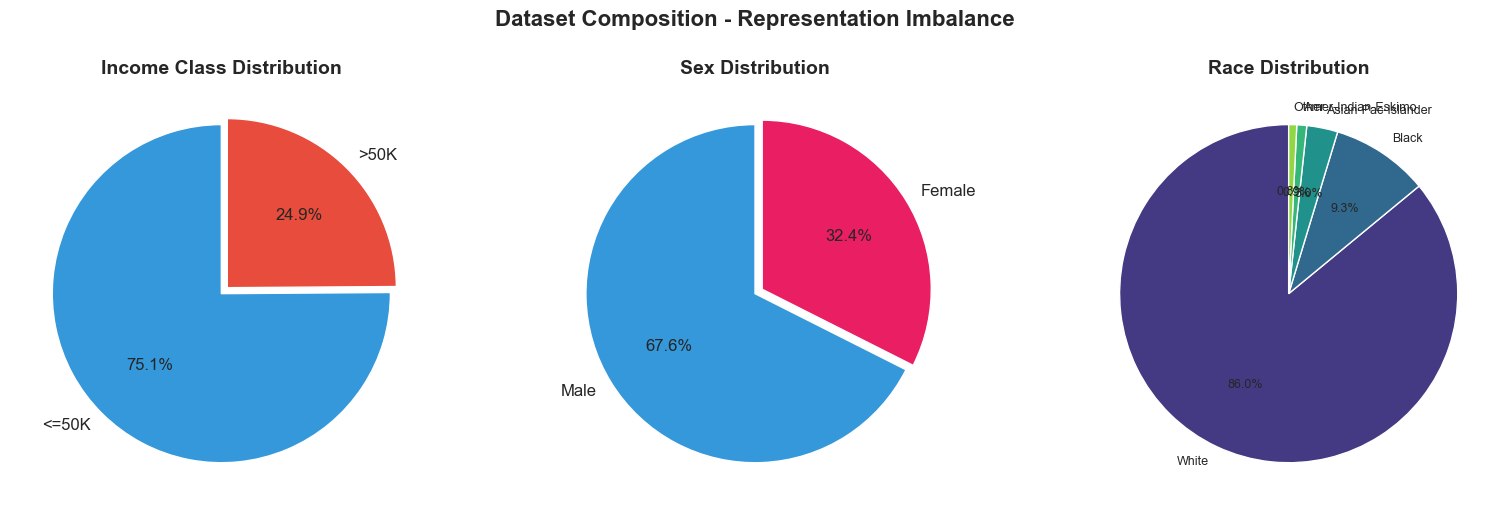

Chart saved as 'charts/dataset_composition.png'


In [11]:
# Create a combined visualization showing dataset composition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Income Class Distribution
income_counts = data['income-class'].value_counts()
colors1 = ['#3498db', '#e74c3c']
axes[0].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', colors=colors1, 
            explode=(0, 0.05), startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Income Class Distribution', fontsize=14, fontweight='bold')

# Plot 2: Sex Distribution
sex_counts = data['sex'].value_counts()
colors2 = ['#3498db', '#e91e63']
axes[1].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=colors2,
            explode=(0, 0.05), startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sex Distribution', fontsize=14, fontweight='bold')

# Plot 3: Race Distribution
race_counts = data['race'].value_counts()
colors3 = sns.color_palette('viridis', len(race_counts))
axes[2].pie(race_counts, labels=race_counts.index, autopct='%1.1f%%', colors=colors3,
            startangle=90, textprops={'fontsize': 9})
axes[2].set_title('Race Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Composition - Representation Imbalance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/dataset_composition.png'")

## 5. Key Interpretations

In [12]:
# Generate interpretation statements
male_high = sex_income_pct.loc['Male', '>50K']
female_high = sex_income_pct.loc['Female', '>50K']
sex_gap = male_high - female_high

white_high = race_income_pct.loc['White', '>50K']
black_high = race_income_pct.loc['Black', '>50K']
race_gap = white_high - black_high

print("=" * 70)
print("DATASET BIAS INTERPRETATION STATEMENTS")
print("=" * 70)
print("\n(Use these in your report)")
print("\n" + "-" * 70)
print("SEX BIAS:")
print("-" * 70)
print(f"• {male_high:.1f}% of males earn >$50K compared to only {female_high:.1f}% of females.")
print(f"• This represents a {sex_gap:.1f} percentage point gap in high-income rates.")
print(f"• Males are {male_high/female_high:.1f}x more likely to earn >$50K than females.")
print(f"• The dataset contains {data['sex'].value_counts()['Male']/data['sex'].value_counts()['Female']:.1f}x more males than females.")

DATASET BIAS INTERPRETATION STATEMENTS

(Use these in your report)

----------------------------------------------------------------------
SEX BIAS:
----------------------------------------------------------------------
• 31.4% of males earn >$50K compared to only 11.4% of females.
• This represents a 20.0 percentage point gap in high-income rates.
• Males are 2.8x more likely to earn >$50K than females.
• The dataset contains 2.1x more males than females.


In [13]:
print("\n" + "-" * 70)
print("RACE BIAS:")
print("-" * 70)

highest_race = race_income_pct['>50K'].idxmax()
lowest_race = race_income_pct['>50K'].idxmin()
highest_val = race_income_pct.loc[highest_race, '>50K']
lowest_val = race_income_pct.loc[lowest_race, '>50K']

print(f"• {highest_race} has the highest >$50K rate at {highest_val:.1f}%.")
print(f"• {lowest_race} has the lowest >$50K rate at {lowest_val:.1f}%.")
print(f"• This represents an {highest_val - lowest_val:.1f} percentage point gap.")
print(f"• White individuals comprise {data['race'].value_counts()['White']/len(data)*100:.1f}% of the dataset.")
print(f"• Non-White groups are severely underrepresented ({100 - data['race'].value_counts()['White']/len(data)*100:.1f}% combined).")


----------------------------------------------------------------------
RACE BIAS:
----------------------------------------------------------------------
• Asian-Pac-Islander has the highest >$50K rate at 27.7%.
• Other has the lowest >$50K rate at 9.1%.
• This represents an 18.6 percentage point gap.
• White individuals comprise 86.0% of the dataset.
• Non-White groups are severely underrepresented (14.0% combined).


In [14]:
print("\n" + "-" * 70)
print("STATISTICAL EVIDENCE:")
print("-" * 70)
print(f"• Chi-square tests confirm statistically significant associations (p < 0.001).")
print(f"• Sex-Income correlation (Cramér's V = {cramers_v_sex:.3f}) is {'stronger' if cramers_v_sex > cramers_v_race else 'weaker'} than")
print(f"  Race-Income correlation (Cramér's V = {cramers_v_race:.3f}).")
print(f"• Both protected attributes are significantly correlated with income class.")

print("\n" + "-" * 70)
print("IMPLICATION FOR FAIRNESS:")
print("-" * 70)
print("• A classifier trained on this data will learn these biased associations.")
print("• Historical income inequality is encoded as predictive patterns.")
print("• Without fairness interventions, the model will perpetuate discrimination.")
print("=" * 70)


----------------------------------------------------------------------
STATISTICAL EVIDENCE:
----------------------------------------------------------------------
• Chi-square tests confirm statistically significant associations (p < 0.001).
• Sex-Income correlation (Cramér's V = 0.217) is stronger than
  Race-Income correlation (Cramér's V = 0.100).
• Both protected attributes are significantly correlated with income class.

----------------------------------------------------------------------
IMPLICATION FOR FAIRNESS:
----------------------------------------------------------------------
• A classifier trained on this data will learn these biased associations.
• Historical income inequality is encoded as predictive patterns.
• Without fairness interventions, the model will perpetuate discrimination.
